In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import example_mujoco
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/mujoco',
        '--file_name', 'hopper',
        '--data_nsample_all', '9850',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--feature_ndim', '14',
        '--target_ndim', '11',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/mujoco',

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 10, "cos": 10}',
        '--embed_exc', '{"data": 20}',
    ]
)

setpoint = torch.zeros(args.target_ndim)

In [3]:
# --! create model, dataset and training

model = kind.model(args)
dataset = mujoco.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.881109, valid=0.554714, test=0.557575
	validation loss decreased (inf -> 0.554714), saving model ...
	epoch 2 losses: train=0.360737, valid=0.265170, test=0.268371
	validation loss decreased (0.554714 -> 0.265170), saving model ...
	epoch 3 losses: train=0.217797, valid=0.171827, test=0.171353
	validation loss decreased (0.265170 -> 0.171827), saving model ...
	epoch 4 losses: train=0.147797, valid=0.129109, test=0.128283
	validation loss decreased (0.171827 -> 0.129109), saving model ...
	epoch 5 losses: train=0.122698, valid=0.114113, test=0.113130
	validation loss decreased (0.129109 -> 0.114113), saving model ...
	epoch 6 losses: train=0.110751, valid=0.103426, test=0.102066
	validation loss decreased (0.114113 -> 0.103426), saving model ...
	epoch 7 losses: train=0.096015, valid=0.085566, test=0.082217
	validation loss decreased (0.103426 -> 0.085566), saving model ...
	epoch 8 losses: train=0.076910, valid=0.070034, test=0.06

In [5]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

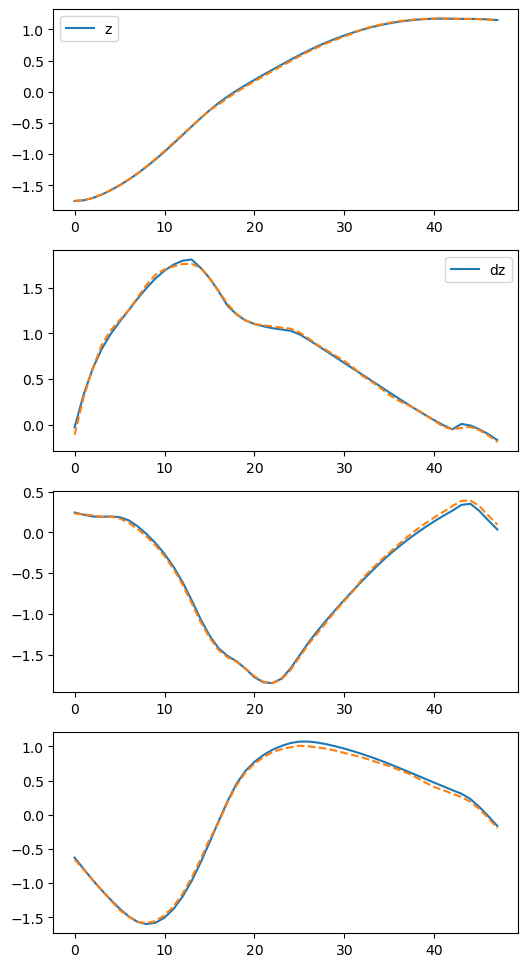

In [21]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(true[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(true[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(true[jdata, :, 1])
        plt.plot(mean_nom[0, :, 1], linestyle='dashed')

        plt.subplot(4,1,4)
        plt.plot(true[jdata, :, 2])
        plt.plot(mean_nom[0, :, 2], linestyle='dashed')

        plt.show()

        break

In [22]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.166320, valid=0.149386, test=0.161056
	validation loss decreased (inf -> 0.149386), saving model ...
	epoch 2 losses: train=0.162019, valid=0.148405, test=0.160151
	validation loss decreased (0.149386 -> 0.148405), saving model ...
	epoch 3 losses: train=0.139610, valid=0.106570, test=0.119217
	validation loss decreased (0.148405 -> 0.106570), saving model ...
	epoch 4 losses: train=0.117278, valid=0.100696, test=0.113985
	validation loss decreased (0.106570 -> 0.100696), saving model ...
	epoch 5 losses: train=0.114063, valid=0.099282, test=0.112851
	validation loss decreased (0.100696 -> 0.099282), saving model ...
	epoch 6 losses: train=0.110175, valid=0.094537, test=0.109387
	validation loss decreased (0.099282 -> 0.094537), saving model ...
	epoch 7 losses: train=0.106424, valid=0.089619, test=0.102052
	validation loss decreased (0.094537 -> 0.089619), saving model ...
	epoch 8 losses: train=0.098303, valid=0.081598, te

In [23]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

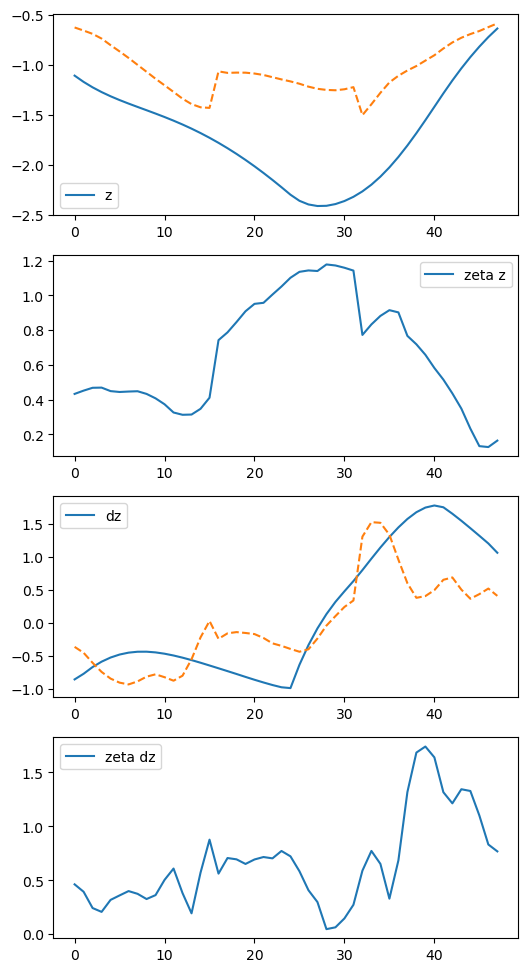

In [28]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta z')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(zeta_nom[0, :, 6], label='zeta dz')
        plt.legend()

        plt.show()

        break

## Train excursion model

In [29]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=1.028709, valid=0.979605, test=0.963347
	validation loss decreased (inf -> 0.979605), saving model ...
	epoch 2 losses: train=0.926490, valid=0.871484, test=0.857713
	validation loss decreased (0.979605 -> 0.871484), saving model ...
	epoch 3 losses: train=0.811822, valid=0.716637, test=0.693129
	validation loss decreased (0.871484 -> 0.716637), saving model ...
	epoch 4 losses: train=0.581662, valid=0.472140, test=0.443368
	validation loss decreased (0.716637 -> 0.472140), saving model ...
	epoch 5 losses: train=0.426017, valid=0.380336, test=0.361743
	validation loss decreased (0.472140 -> 0.380336), saving model ...
	epoch 6 losses: train=0.347124, valid=0.306116, test=0.299387
	validation loss decreased (0.380336 -> 0.306116), saving model ...
	epoch 7 losses: train=0.276835, valid=0.235141, test=0.236963
	validation loss decreased (0.306116 -> 0.235141), saving model ...
	epoch 8 losses: train=0.221768, valid=0.189933, test=0.

In [30]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

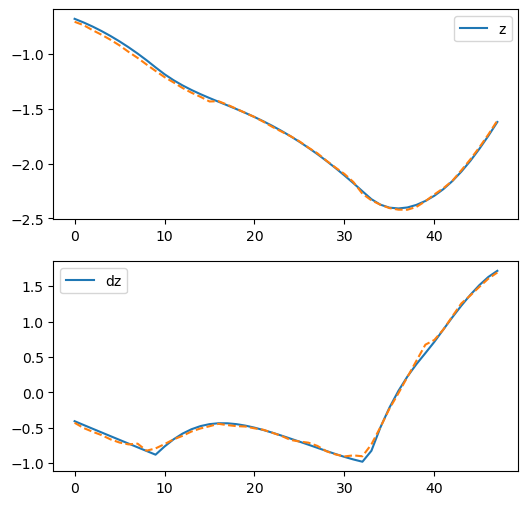

In [41]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_exc[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.show()

        break

## Train excursion uncertainty

In [42]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.448520, valid=0.372915, test=0.359608
	validation loss decreased (inf -> 0.372915), saving model ...
	epoch 2 losses: train=0.291479, valid=0.269630, test=0.261803
	validation loss decreased (0.372915 -> 0.269630), saving model ...
	epoch 3 losses: train=0.257113, valid=0.252404, test=0.246262
	validation loss decreased (0.269630 -> 0.252404), saving model ...
	epoch 4 losses: train=0.219726, valid=0.175186, test=0.173789
	validation loss decreased (0.252404 -> 0.175186), saving model ...
	epoch 5 losses: train=0.162536, valid=0.155664, test=0.154447
	validation loss decreased (0.175186 -> 0.155664), saving model ...
	epoch 6 losses: train=0.150331, valid=0.146184, test=0.145270
	validation loss decreased (0.155664 -> 0.146184), saving model ...
	epoch 7 losses: train=0.140356, valid=0.133972, test=0.133128
	validation loss decreased (0.146184 -> 0.133972), saving model ...
	epoch 8 losses: train=0.128997, valid=0.126188, 

In [43]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

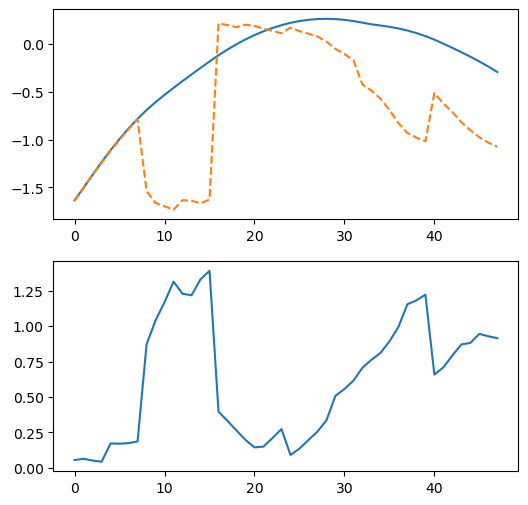

In [47]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc
        zeta_exc = model_o.zeta_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_exc[0, :, :1])

        plt.show()

        break

## Evaluate KIND blending

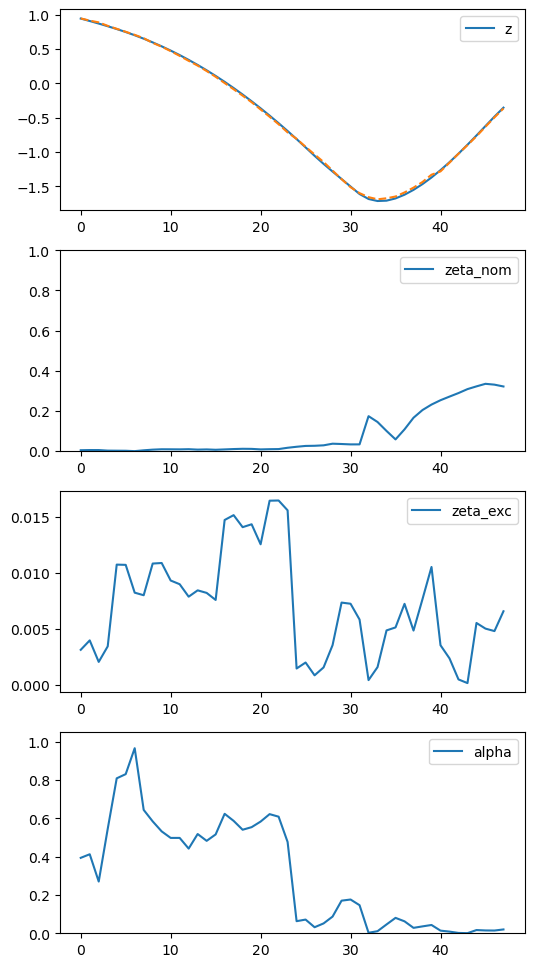

In [59]:
jdata = 11

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pred = model_o.blend
        zeta_nom = model_o.zeta_nom
        zeta_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(pred[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(zeta_exc[0, :, :1], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :1], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break